# Неделя 3: обучение без учителя
## Временные ряды

В этом задании тебе предстоит проанализировать продажи разных категорий товаров. Сначала это стоит сделать для одной категории, потом можно попробовать для других. 

1. Загрузи [датасет](https://community.tableau.com/s/question/0D54T00000CWeX8SAL/sample-superstore-sales-excelxls) и распечатай первые 10 строк. 

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import statsmodels.api as sm

from sklearn.metrics import mean_squared_error
from tqdm import tqdm

warnings.filterwarnings('ignore')

In [61]:
plt.style.use('seaborn')

In [62]:
df = pd.read_excel('aux/Sample - Superstore.xls')
df = df[df['Category'] == 'Furniture']

Сделай выбоорку по категории товара (используй популярную категорию: например, `Furniture`) и запиши в переменную `data`. Распечатай первые 10 строк. 

In [63]:
data = df[df['Category'] == 'Furniture'].set_index('Ship Date')['Sales']

2. Визуализируй данные:
    * по исходному целевому столбцу (`Sales`)
    * усреднить.просуммировать по разным периодам

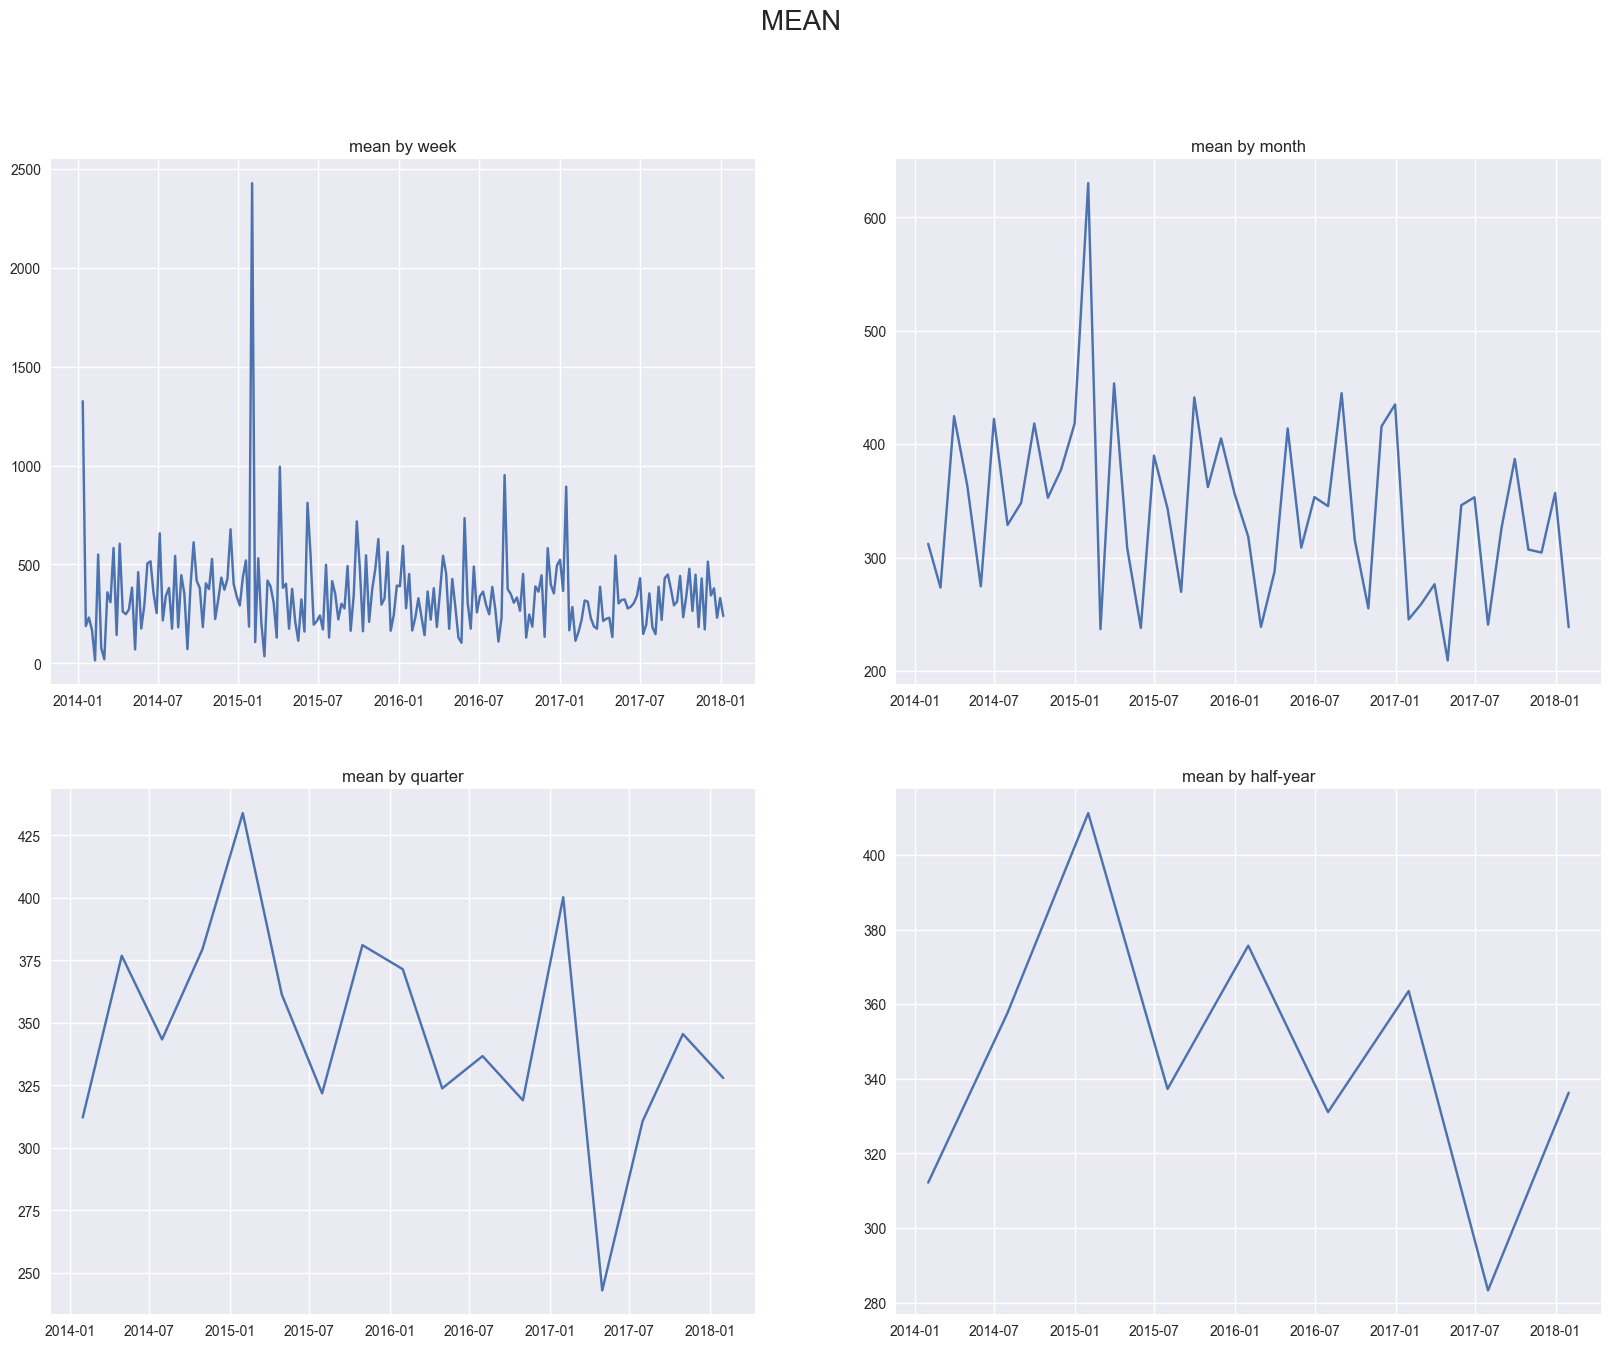

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(20,15))

axes[0][0].plot(data.resample('1W').mean())
axes[0][0].set_title('mean by week')

axes[0][1].plot(data.resample('1M').mean())
axes[0][1].set_title('mean by month')

axes[1][0].plot(data.resample('3M').mean())
axes[1][0].set_title('mean by quarter')

axes[1][1].plot(data.resample('6M').mean())
axes[1][1].set_title('mean by half-year')

plt.suptitle('MEAN', size=20);

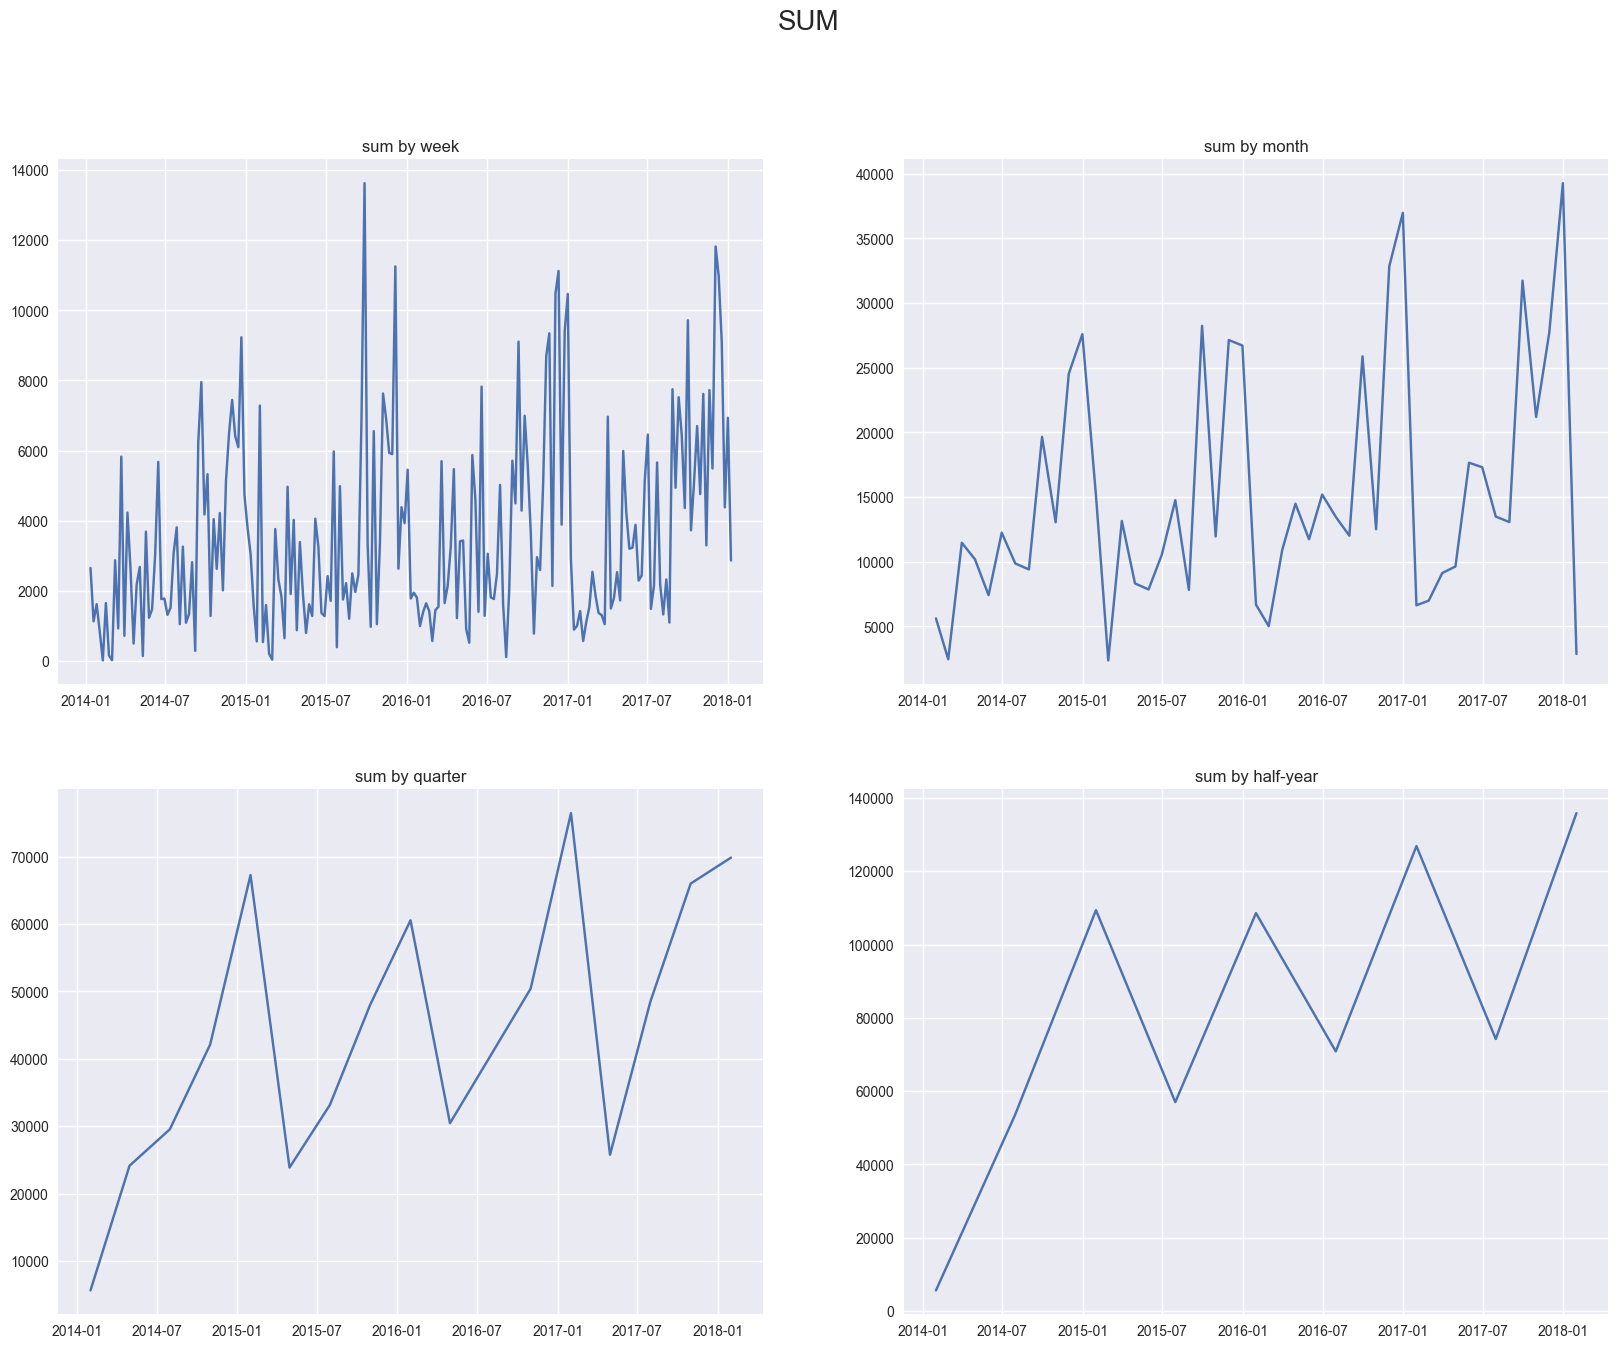

In [65]:
fig, axes = plt.subplots(2, 2, figsize=(20,15))

axes[0][0].plot(data.resample('1W').sum())
axes[0][0].set_title('sum by week')

axes[0][1].plot(data.resample('1M').sum())
axes[0][1].set_title('sum by month')

axes[1][0].plot(data.resample('3M').sum())
axes[1][0].set_title('sum by quarter')

axes[1][1].plot(data.resample('6M').sum())
axes[1][1].set_title('sum by half-year')

plt.suptitle('SUM', size=20);

2.1 В качестве анализа необходимо взять временной ряд по месяцам, и анализировать сумму. 

In [66]:
data = data.resample('1M').sum()

* Под валидацию выделю 2017 год +

In [67]:
data_train = data[data.index.year < 2017]
data_test = data[data.index.year >= 2017]

3. Построй визуализации:
* скользящего среднего


* Для примера выведем DataFrame с предсказанием вида 'Завтра будет как вчера'. Иначе говоря длина окна равна 1.

In [68]:
pd.DataFrame(data= {'real': data, 'pred': data.rolling(window=1, closed='left').mean()}, index=data.index)

,real,pred
Ship Date,,
2014-01-31,5618.8590,NaN
2014-02-28,2463.3240,5618.8590
2014-03-31,11468.0530,2463.3240
2014-04-30,10189.4560,11468.0530
2014-05-31,7418.6160,10189.4560
2014-06-30,12247.1356,7418.6160
2014-07-31,9865.7040,12247.1356
2014-08-31,9405.4000,9865.7040
2014-09-30,19658.4753,9405.4000


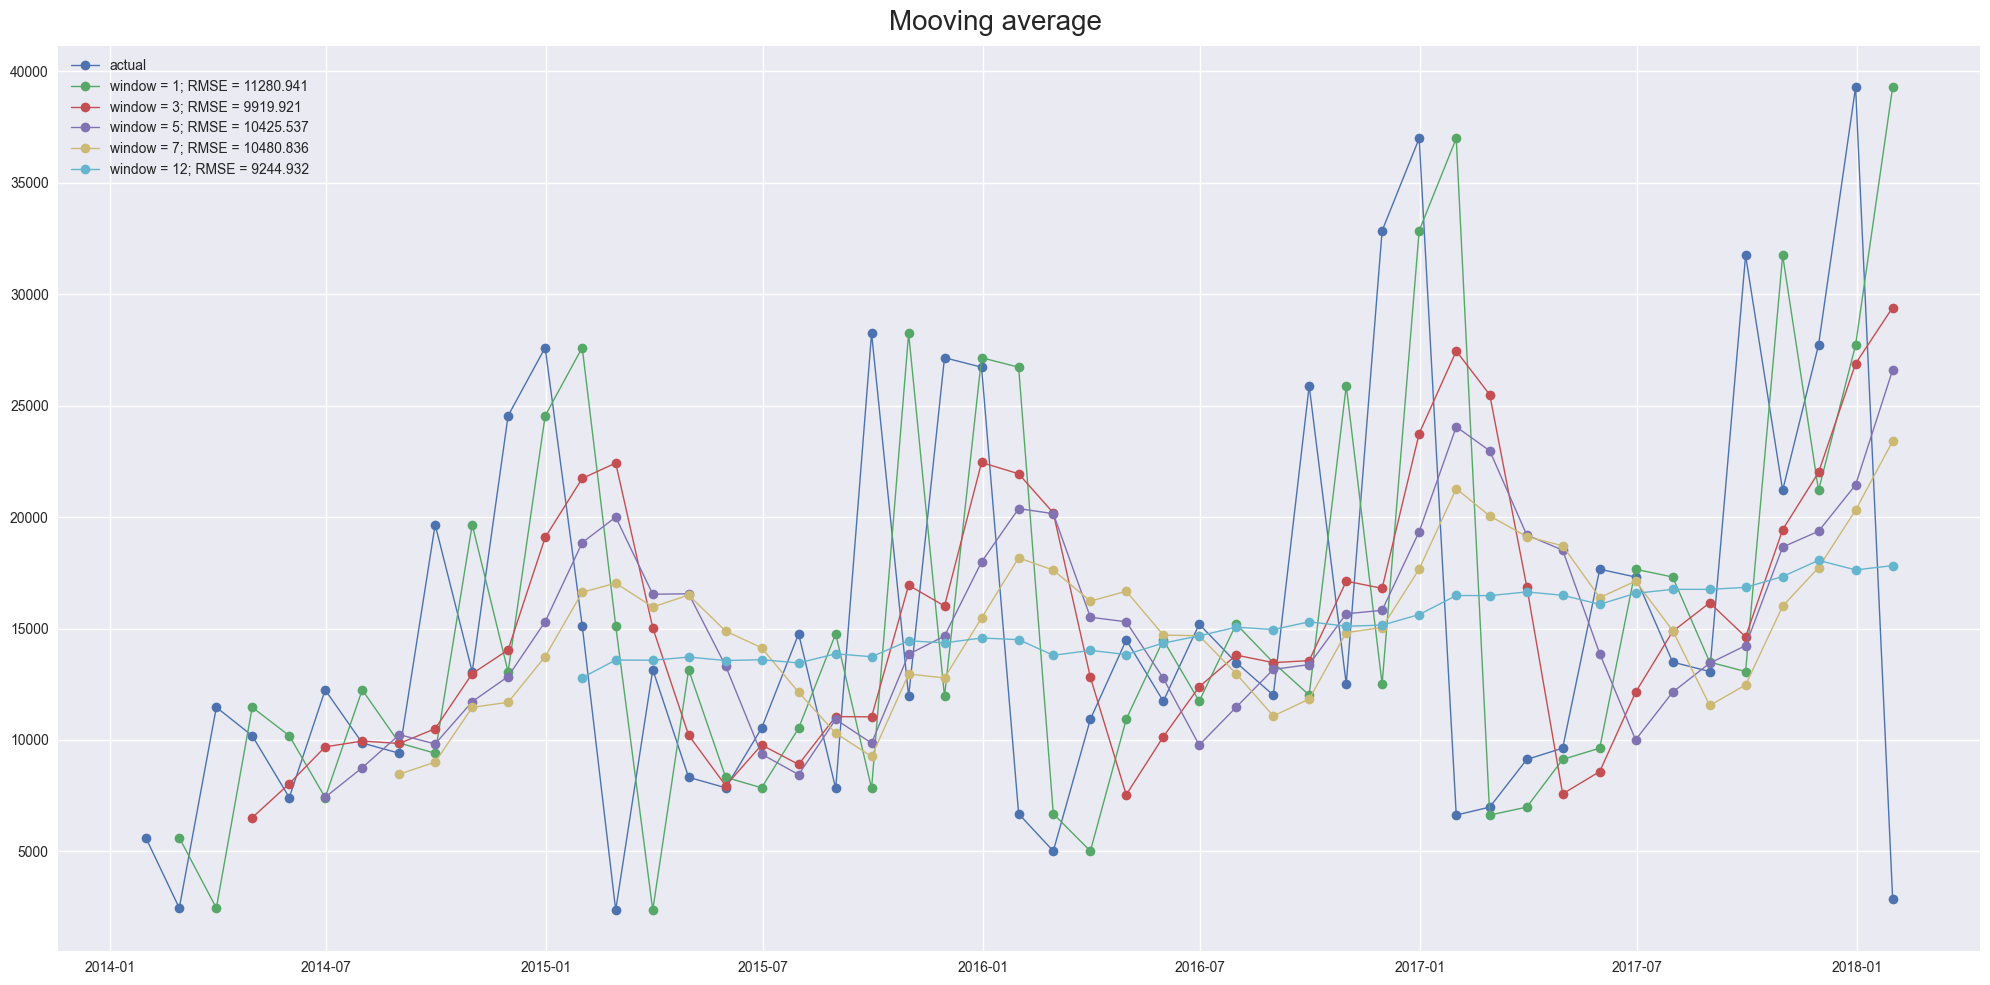

In [69]:
windows = [1, 3, 5, 7, 12]

plt.figure(figsize=(20, 10))
plt.plot(data.rolling(window=1).mean(), label='actual', marker='o', linewidth=1);

for window in windows:
    data_pred = data.rolling(window=window, closed='left').mean()
    rmse = mean_squared_error(data[window:], data_pred[window:], squared=False)
    plt.plot(data_pred, label=f'window = {window}; RMSE = {round(rmse, 3)}', marker='o', linewidth=1)
    

plt.suptitle('Mooving average', size=20)
plt.tight_layout()
    
plt.legend();


* взвешенного скользящего среднего


In [70]:
def wma(x, n, weights):
    weights = np.array(weights)
    wmas = x.shift(1).rolling(n).apply(lambda x: np.dot(x, weights) /
                                       weights.sum(), raw=True).to_list()
    return wmas

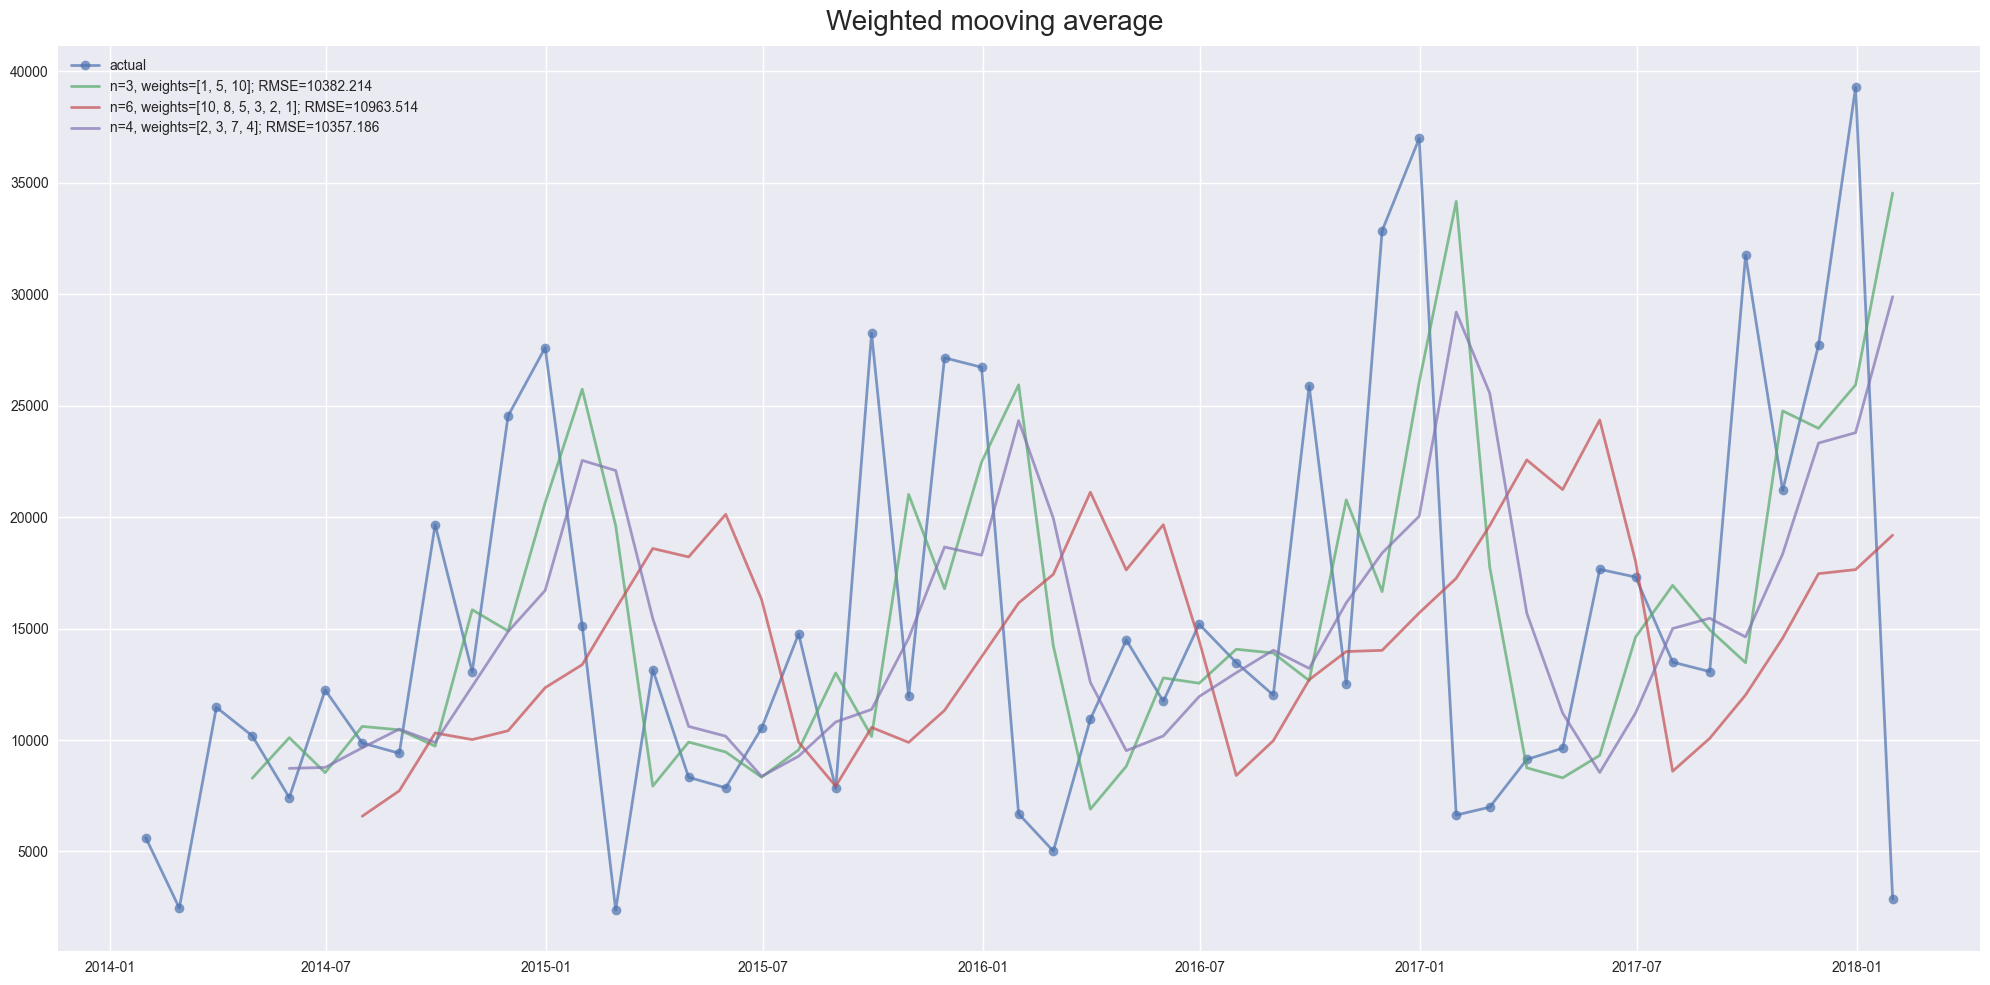

In [71]:
plt.figure(figsize=(20, 10))

plt.plot(data.index, data.values,
         linewidth=2, label='actual', alpha=.7, marker='o')

set_of_weights = [[1,5,10], [10, 8, 5, 3, 2, 1], [2, 3, 7, 4]]

for weights in set_of_weights:
    data_pred = wma(data, len(weights), weights)
    rmse = mean_squared_error(data[len(weights):], data_pred[len(weights):], squared=False)
    
    plt.plot(
        data.index, 
        data_pred, 
        linewidth=2, 
        label=f'n={len(weights)}, weights={weights}; RMSE={round(rmse, 3)}', alpha=.7
    )
plt.suptitle('Weighted mooving average', size=20)
plt.tight_layout()
plt.legend();

Какие выводы можно сделать по скользящим линиям? Что они показывают?

3. Реализуйте экспоненциальное, двойное экспоненциальное и тройное экспоненциальное сглаживание (модель [Хольта-Уинтерса](https://www.statsmodels.org/dev/generated/statsmodels.tsa.holtwinters.Holt.html))

In [72]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing

1. Простое сглаживание 

In [73]:
simp_exp = SimpleExpSmoothing(data, initialization_method="heuristic").fit(
    smoothing_level=0.2, optimized=False
    )

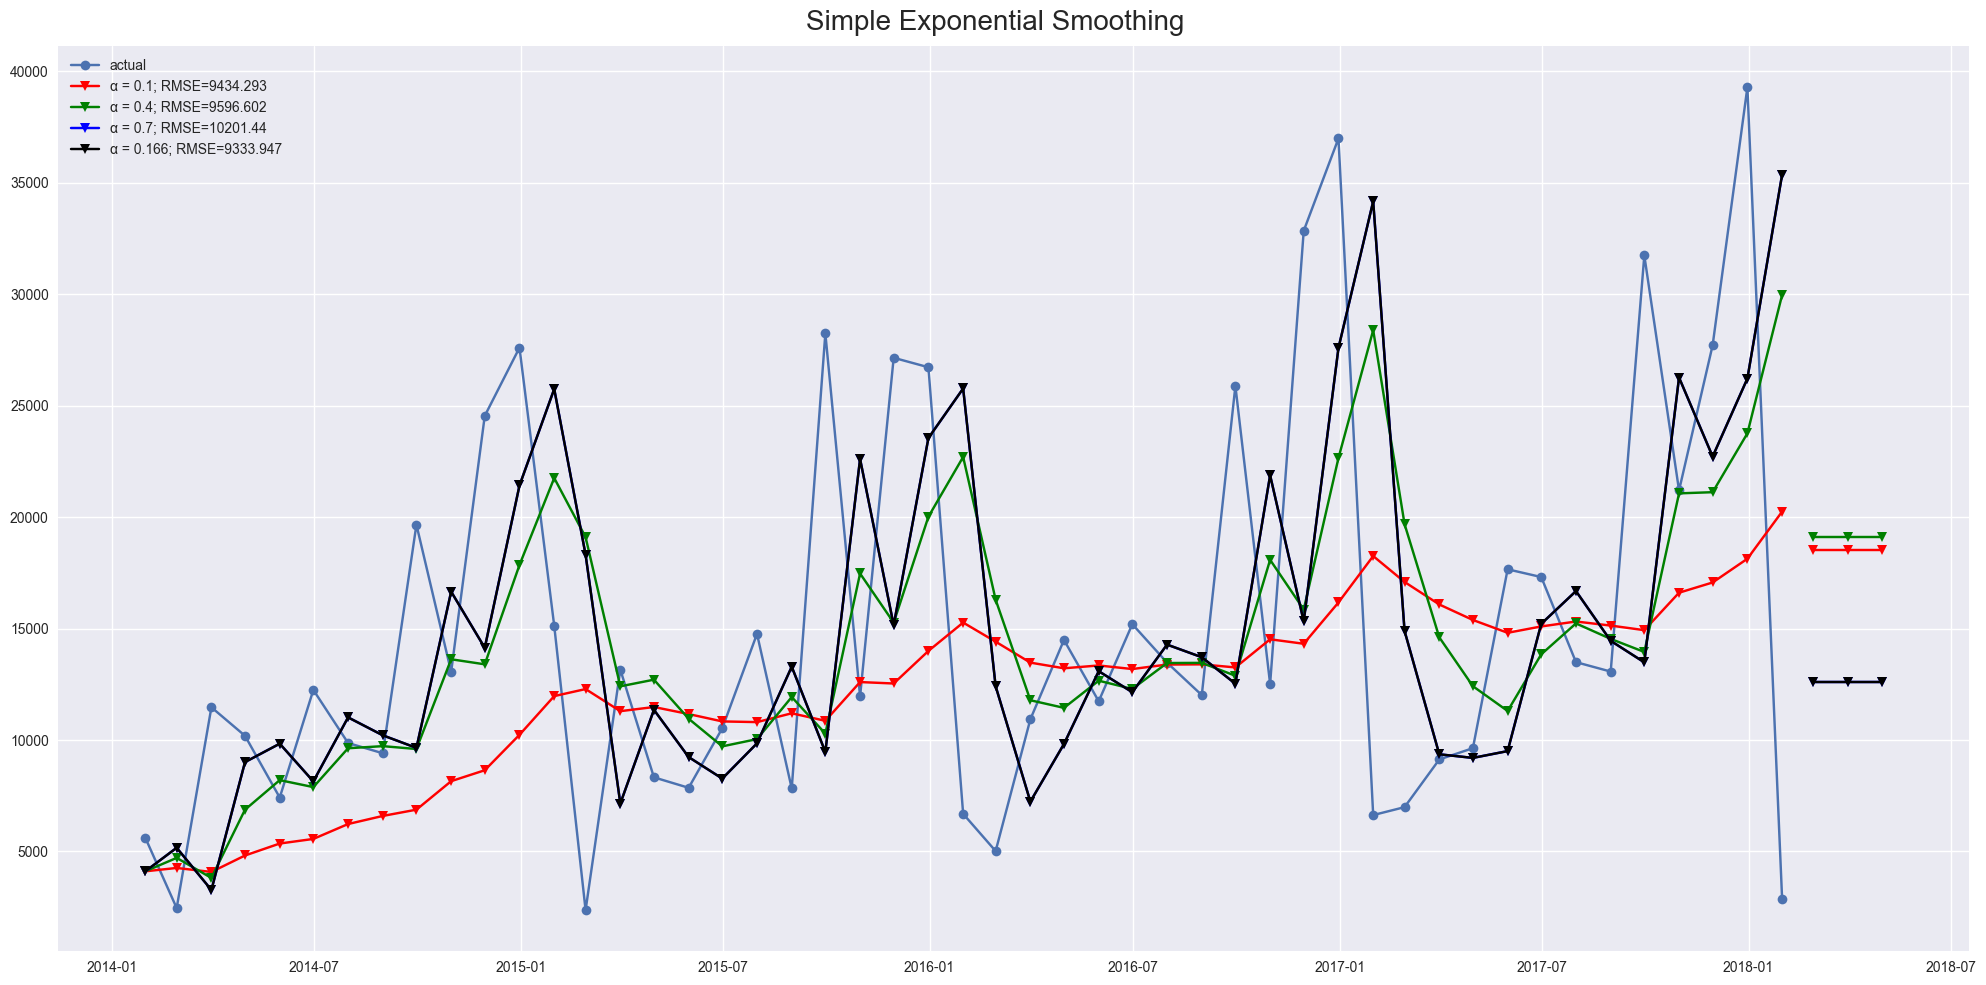

In [74]:
plt.figure(figsize=(20, 10))
plt.plot(data, label='actual', marker='o')

smoothing_levels = np.arange(0.1, 1, 0.3)

colors = ['r', 'g', 'b']

plt.suptitle('Simple Exponential Smoothing', size=20)
for smoothing_level, color in zip(smoothing_levels, colors):
    simp_exp = SimpleExpSmoothing(data, initialization_method="heuristic").fit(
    smoothing_level=smoothing_level, optimized=False
    )
    data_pred = simp_exp.fittedvalues
    
    simp_exp_fcast = simp_exp.forecast(3)
    
    alpha = round(simp_exp.params['smoothing_level'], 1)
    
    rmse = round(mean_squared_error(data, data_pred, squared=False), 3)
    
    plt.plot(simp_exp.fittedvalues, label=f'\u03B1 = {alpha}; RMSE={rmse}', marker='v', color=color)
    plt.plot(simp_exp_fcast, marker='v', color=color)
    
best_simp_exp = SimpleExpSmoothing(data, initialization_method="heuristic").fit(
    optimized=True
    )
data_pred = best_simp_exp.fittedvalues
best_simp_exp_fcast = best_simp_exp.forecast(3)
alpha = round(best_simp_exp.params['smoothing_level'], 3)
rmse = round(mean_squared_error(data, data_pred, squared=False), 3)

plt.plot(simp_exp.fittedvalues, label=f'\u03B1 = {alpha}; RMSE={rmse}', marker='v', color='k')
plt.plot(simp_exp_fcast, marker='v', color='k')
    
plt.tight_layout()
plt.legend();

2. Двойное экспоненциальное сглаживание

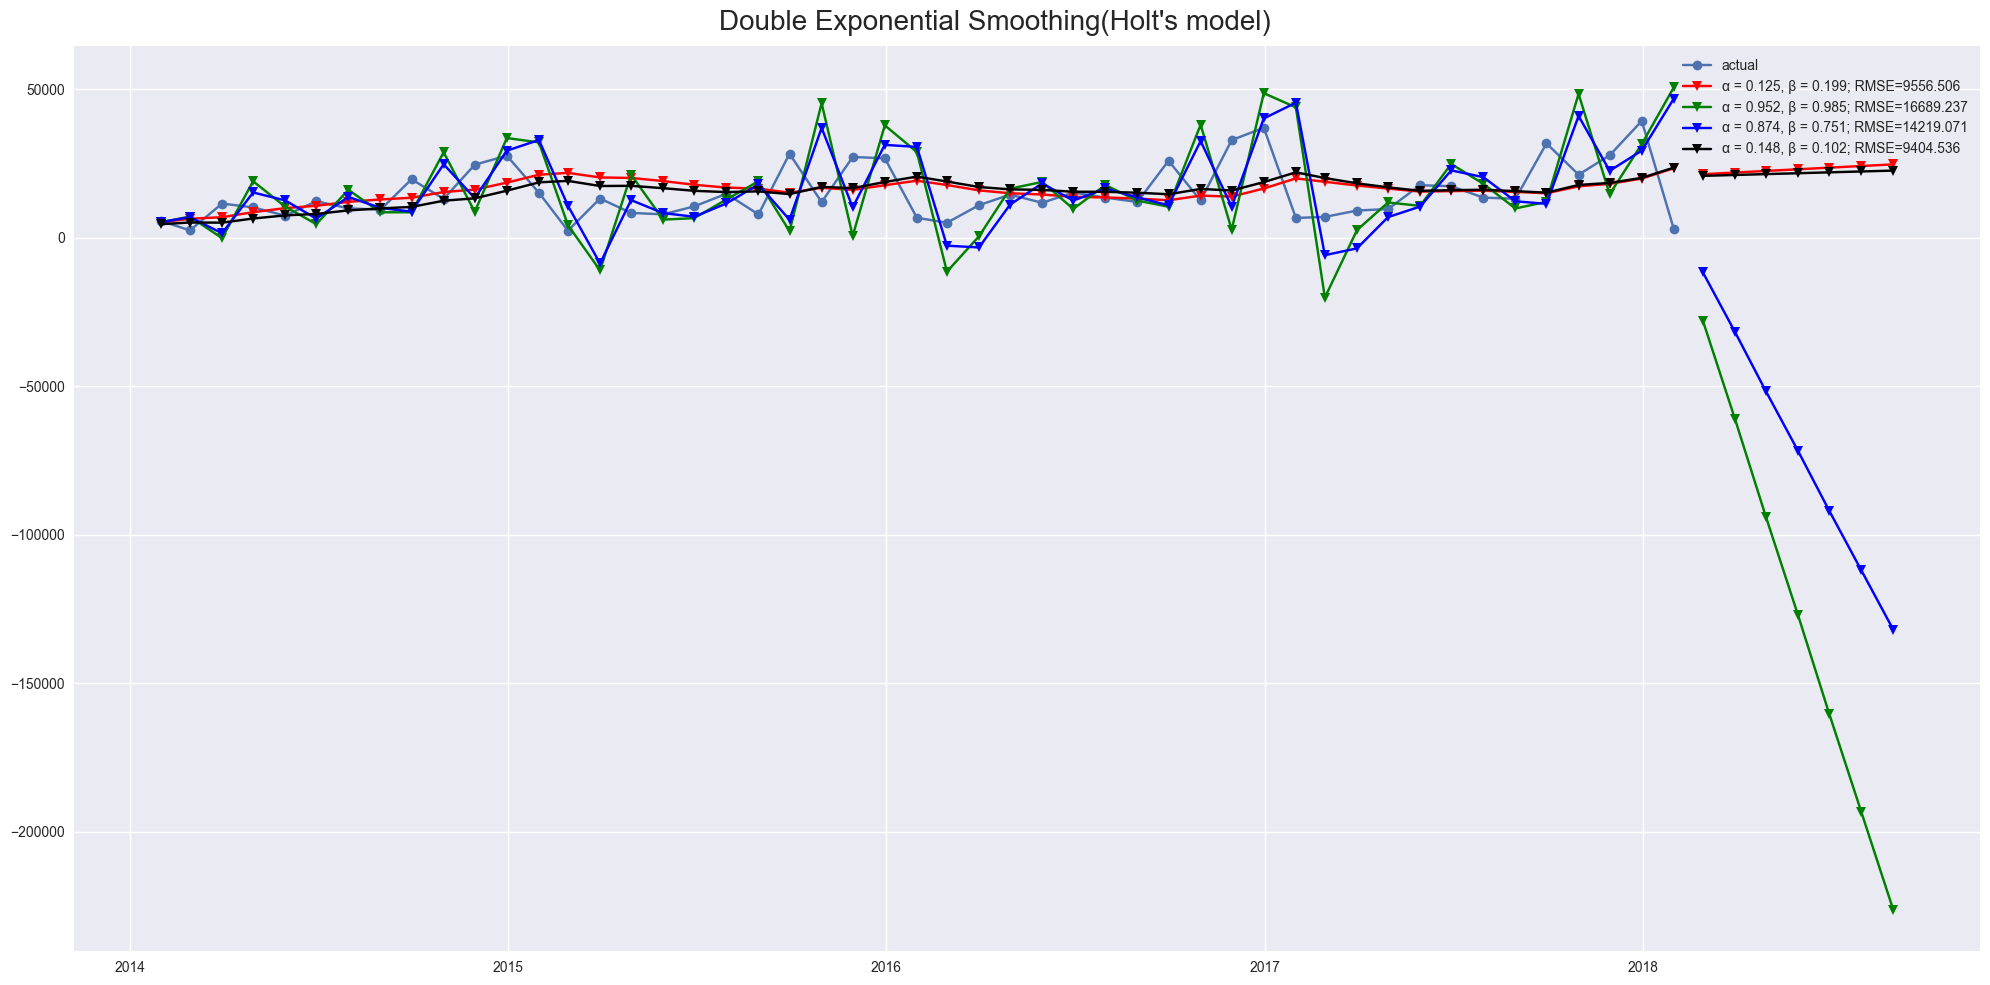

In [75]:
plt.figure(figsize=(20, 10))
plt.plot(data, label='actual', marker='o')

smoothing_levels = np.round(np.random.uniform(size=3), 3)
smoothing_trends = np.round(np.random.uniform(size=3), 3)

colors = ['r', 'g', 'b']

plt.suptitle('Double Exponential Smoothing(Holt\'s model)', size=20)
for smoothing_level, smoothing_trend, color in zip(smoothing_levels, smoothing_trends, colors):
    double_exp = Holt(data, initialization_method="estimated").fit(
    smoothing_level=smoothing_level,
    smoothing_trend=smoothing_trend,
    optimized=False
    )
    data_pred = double_exp.fittedvalues
    
    double_exp_fcast = double_exp.forecast(7)
    
    alpha = double_exp.params['smoothing_level']
    betta = double_exp.params['smoothing_trend']
    
    rmse = round(mean_squared_error(data, data_pred, squared=False), 3)
    
    plt.plot(double_exp.fittedvalues, label=f'\u03B1 = {alpha}, \u03B2 = {betta}; RMSE={rmse}', marker='v', color=color)
    plt.plot(double_exp_fcast, marker='v', color=color)
    
best_double_exp = Holt(data, initialization_method="estimated").fit(
    optimized=True
    )
data_pred = best_double_exp.fittedvalues
best_double_exp_fcast = best_double_exp.forecast(7)
alpha = round(best_double_exp.params['smoothing_level'], 3)
betta = round(best_double_exp.params['smoothing_trend'], 3)
rmse = round(mean_squared_error(data, data_pred, squared=False), 3)

plt.plot(best_double_exp.fittedvalues, label=f'\u03B1 = {alpha}, \u03B2 = {betta}; RMSE={rmse}', marker='v', color='k')
plt.plot(best_double_exp_fcast, marker='v', color='k')
    
plt.tight_layout()
plt.legend();

3. Тройное экспоненциальное сглаживание

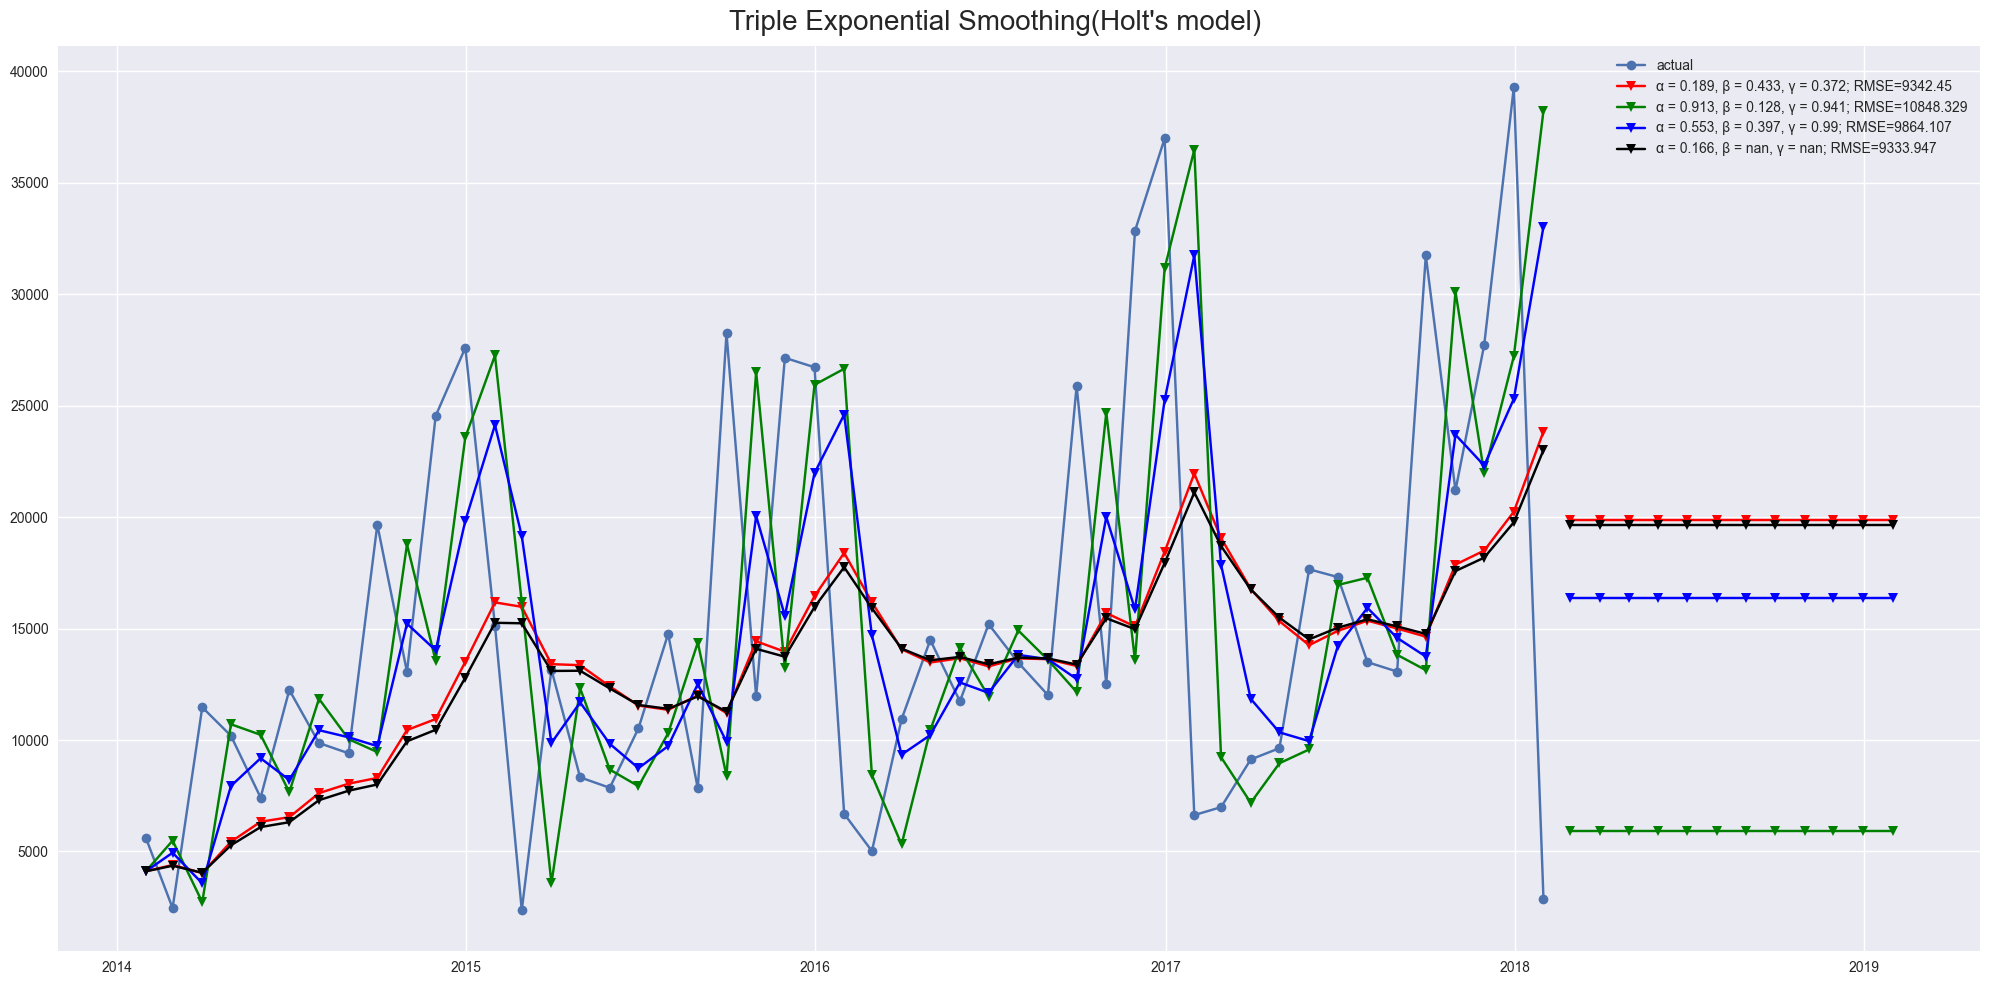

In [76]:
plt.figure(figsize=(20, 10))
plt.plot(data, label='actual', marker='o')

smoothing_levels = np.round(np.random.uniform(size=3), 3)
smoothing_trends = np.round(np.random.uniform(size=3), 3)
smoothing_seasonals = np.round(np.random.uniform(size=3), 3)

colors = ['r', 'g', 'b']

plt.suptitle('Triple Exponential Smoothing(Holt\'s model)', size=20)
for smoothing_level, smoothing_trend, smoothing_seasonal, color in zip(smoothing_levels, smoothing_trends, smoothing_seasonals, colors):
    triple_exp = ExponentialSmoothing(data, initialization_method="estimated", seasonal_periods=12).fit(
        smoothing_level=smoothing_level,
        smoothing_trend=smoothing_trend,
        smoothing_seasonal=smoothing_seasonal,
        optimized=False
    )
    data_pred = triple_exp.fittedvalues
    
    triple_exp_fcast = triple_exp.forecast(12)
    
    alpha = triple_exp.params['smoothing_level']
    beta = triple_exp.params['smoothing_trend']
    gamma = triple_exp.params['smoothing_seasonal']
    
    rmse = round(mean_squared_error(data, data_pred, squared=False), 3)
    
    plt.plot(data_pred, label=f'\u03B1 = {alpha}, \u03B2 = {beta}, \u03B3 = {gamma}; RMSE={rmse}', marker='v', color=color)
    plt.plot(triple_exp_fcast, marker='v', color=color)

    
best_triple_exp = SimpleExpSmoothing(data, initialization_method="estimated").fit(
    optimized=True
    )
data_pred = best_triple_exp.fittedvalues
best_triple_exp_fcast = best_triple_exp.forecast(12)
alpha = round(best_triple_exp.params['smoothing_level'], 3)
betta = round(best_triple_exp.params['smoothing_trend'], 3)
gamma = round(best_triple_exp.params['smoothing_seasonal'], 3)
rmse = round(mean_squared_error(data, data_pred, squared=False), 3)

plt.plot(best_triple_exp.fittedvalues, label=f'\u03B1 = {alpha}, \u03B2 = {betta}, \u03B3 = {gamma}; RMSE={rmse}', marker='v', color='k')
plt.plot(best_triple_exp_fcast, marker='v', color='k')
    
plt.tight_layout()
plt.legend();

4. Декомпозируй данные на тренд, сезонность и остатки. 

<Figure size 1500x1400 with 0 Axes>

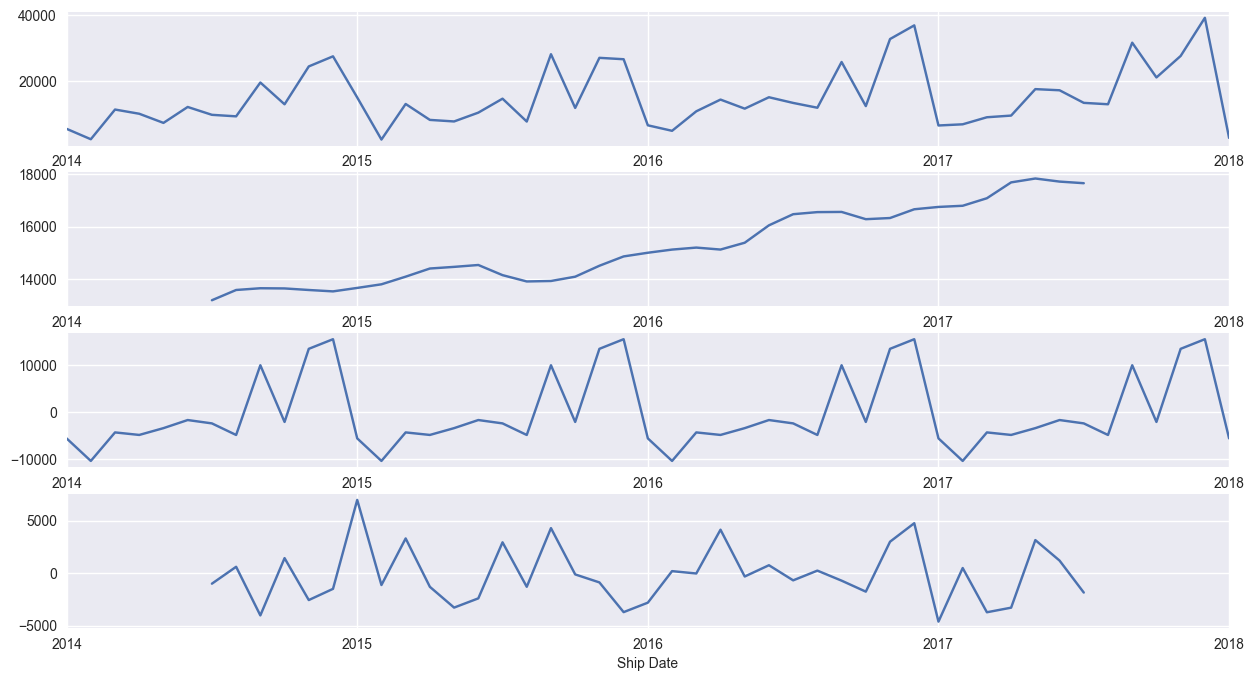

In [77]:
from statsmodels.tsa.seasonal import seasonal_decompose


plt.figure(figsize=(15, 14))

fig, (ax1,ax2,ax3, ax4) = plt.subplots(4,1, figsize=(15,8))
res = seasonal_decompose(data)
res.observed.plot(ax=ax1)
res.trend.plot(ax=ax2)
res.seasonal.plot(ax=ax3)
res.resid.plot(ax=ax4)

plt.show();

# ❓
Прокомментируй графики: какой вывод можно сделать? Есть ли в данных сезонность? Какой тренд преобладает? Какого масштаба ошибки по сравнению со значениями основного временного ряда?

> ответ тут

5. Построй графики автокорреляционной функции и частичной автокорреляционной функции. 

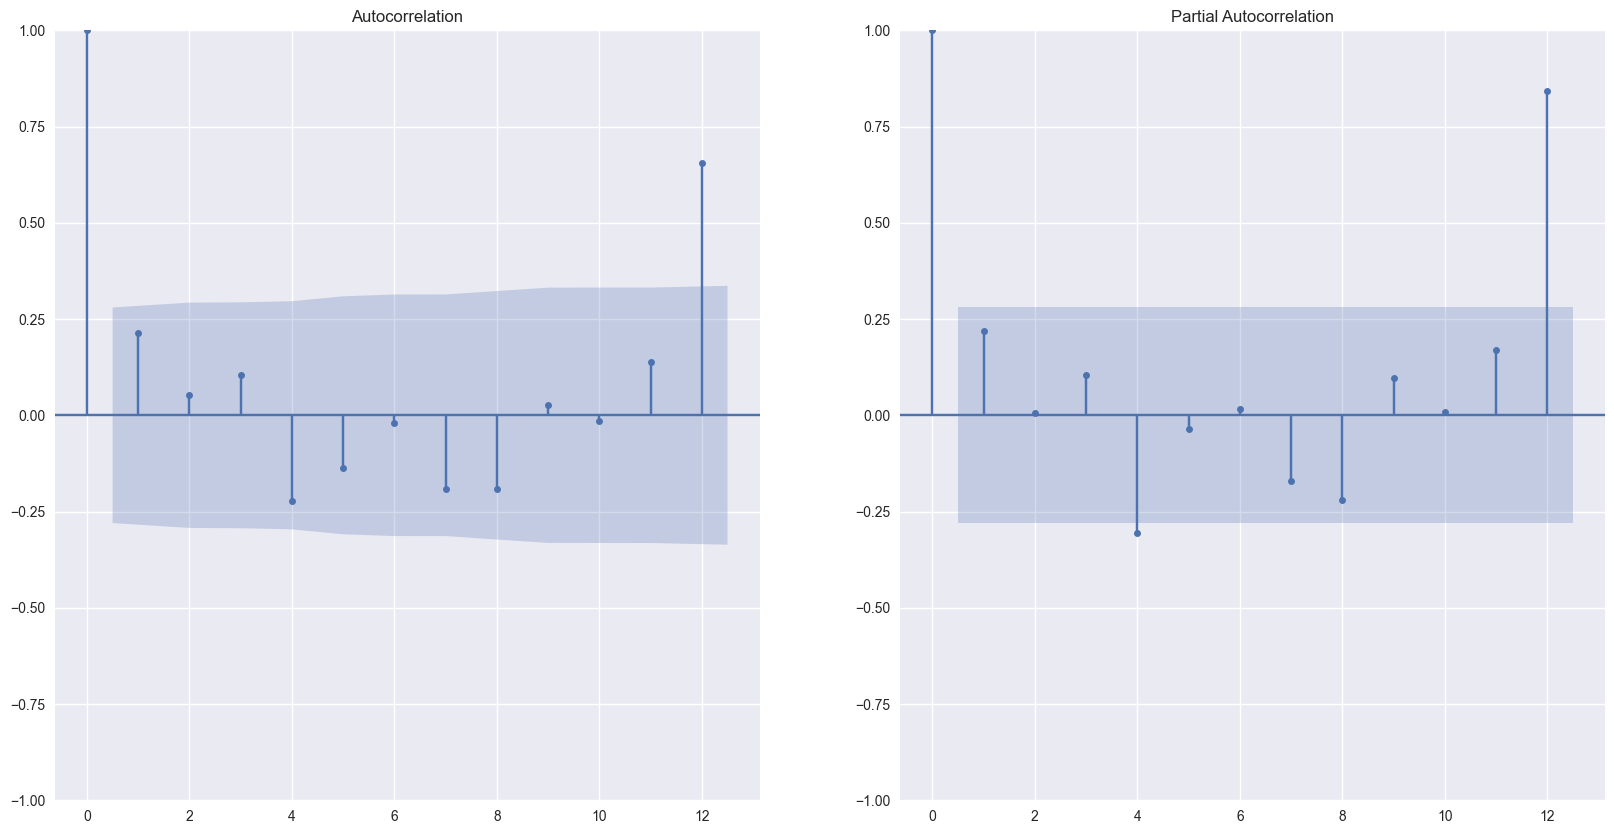

In [78]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
n_lags = 12
acf = plot_acf(data, ax=ax1, lags=n_lags)
pacf = plot_pacf(data, ax=ax2, lags=n_lags)

# ❓
Какие выводы можно сделать на основе этих графиков?

> ответ тут

6. Постройте модель класса ARIMA

In [79]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX


print(f'p-value исходного временного ряда - {adfuller(data)[1]}')

p-value исходного временного ряда - 0.8218995040596897


In [80]:
print(f'p-value после дифференциации временного ряда - {adfuller(np.diff(data))[1]}')

p-value после дифференциации временного ряда - 3.8139089927584736e-24


In [81]:
diff_data = np.diff(data)

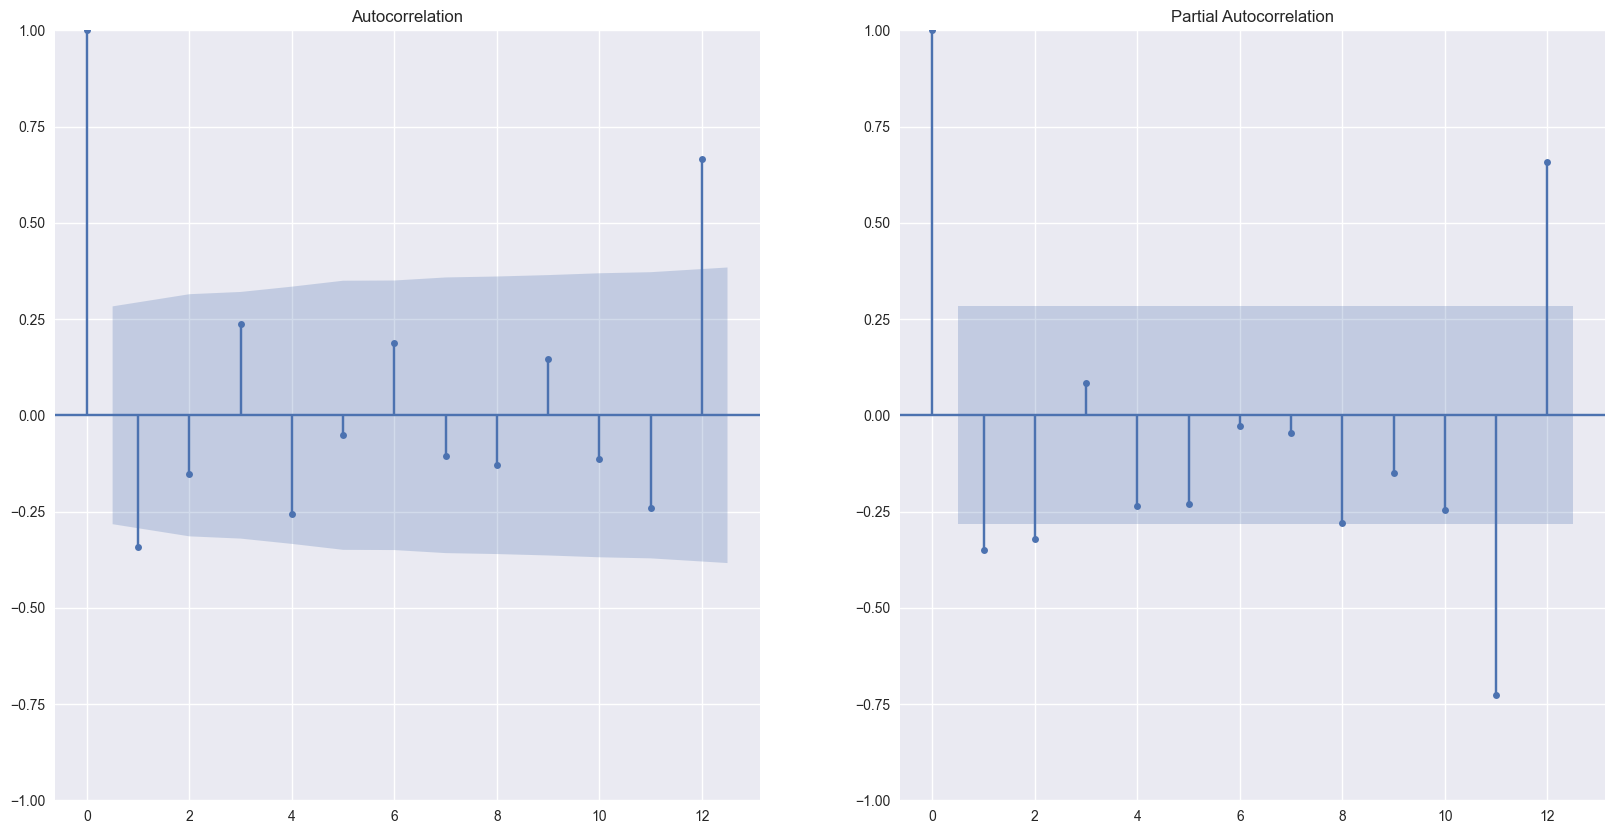

In [82]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
n_lags = 12
acf = plot_acf(diff_data, ax=ax1, lags=n_lags)
pacf = plot_pacf(diff_data, ax=ax2, lags=n_lags)

In [83]:
ps = range(0, 3)
d = range(0, 2)
qs = range(0, 3)
Ps = range(0, 3)
D = range(0, 2)
Qs = range(0, 3)
s=12


from itertools import product
parameters = product(ps, d, qs, Ps, D, Qs)
parameters_list = list(parameters)

In [84]:
def optimizeSARIMA(series, parameters_list, s):
    """
        Return dataframe with parameters and corresponding AIC
        
        series – the time series
        parameters_list - list with (p, q, P, Q) tuples
        d - integration order in ARIMA model
        D - seasonal integration order 
        s - length of season
    """

    results = []
    best_aic = float("inf")

    for param in tqdm(parameters_list):
        # we need try-except because on some combinations model fails to converge
        try:
            model = SARIMAX(
                series,
                order=(param[0], param[1], param[2]),
                seasonal_order=(param[3], param[4], param[5], s),
            ).fit(disp=-1)
            aic = model.aic
        except:
            continue
        # saving best model, AIC and parameters
        if aic < best_aic:
            best_model = model
            best_aic = aic
            best_param = param
        results.append([param, model.aic])

    result_table = pd.DataFrame(results)
    print(results)
    result_table.columns = ["parameters", "aic"]
    # sorting in ascending order, the lower AIC is - the better
    result_table = result_table.sort_values(by="aic", ascending=True).reset_index(
        drop=True
    )

    return result_table

* Посчитаем по сетке параметров топ тюнинга в контексте метрики 'AIC' - которая агрегирует в себе две вещи - простоту и точность модели

In [85]:
result_table = optimizeSARIMA(data_train, parameters_list, s)

100%|█████████████████████████████████████████| 324/324 [01:10<00:00,  4.57it/s]

[[(0, 0, 0, 0, 0, 0), 805.0491489211307], [(0, 0, 0, 0, 0, 1), 786.793742944227], [(0, 0, 0, 0, 0, 2), 774.649360470981], [(0, 0, 0, 0, 1, 0), 475.95805692383055], [(0, 0, 0, 0, 1, 1), 477.74282703149424], [(0, 0, 0, 0, 1, 2), 475.06082539876707], [(0, 0, 0, 1, 0, 0), 745.4979947564321], [(0, 0, 0, 1, 0, 1), 744.023063179601], [(0, 0, 0, 1, 0, 2), 760.8040486478159], [(0, 0, 0, 1, 1, 0), 477.770150036475], [(0, 0, 0, 1, 1, 1), 476.8772490066568], [(0, 0, 0, 1, 1, 2), 477.06087720478877], [(0, 0, 0, 2, 0, 0), 743.9964908573493], [(0, 0, 0, 2, 0, 1), 749.3859900601486], [(0, 0, 0, 2, 0, 2), 762.7951402925233], [(0, 0, 0, 2, 1, 0), 475.0911584741087], [(0, 0, 0, 2, 1, 1), 477.05749004697975], [(0, 0, 0, 2, 1, 2), 479.06168242066303], [(0, 0, 1, 0, 0, 0), 786.8887935313903], [(0, 0, 1, 0, 0, 1), 790.268645198103], [(0, 0, 1, 0, 0, 2), 790.9279471828929], [(0, 0, 1, 0, 1, 0), 476.19242632953996], [(0, 0, 1, 0, 1, 1), 478.0848765377062], [(0, 0, 1, 0, 1, 2), 476.83943903637123], [(0, 0, 1, 1

* Найдем топ RMSE на тестовой выборке

In [86]:
# p, q, P, Q = result_table.parameters[3]

best_rmse = 10000
for i in range(100):

    p, d, q, P, D, Q = result_table['parameters'][i]

    best_model = SARIMAX(
        data_train, order=(p, d, q), seasonal_order=(P, D, Q, s)
    ).fit(disp=-1)
    rmse = mean_squared_error(data_test, best_model.predict(start=data_test.index[0], end=data_test.index[-1]), squared=False)
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_params = i
        
best_params = result_table['parameters'][best_params]
        
print(f'Лучший RMSE: {best_rmse}, при параметрах - {best_params} и сезонности s = 12')

Лучший RMSE: 4109.827200030215, при параметрах - (2, 0, 1, 0, 1, 2) и сезонности s = 12


In [87]:
data_train

Ship Date
2014-01-31     5618.8590
2014-02-28     2463.3240
2014-03-31    11468.0530
2014-04-30    10189.4560
2014-05-31     7418.6160
2014-06-30    12247.1356
2014-07-31     9865.7040
2014-08-31     9405.4000
2014-09-30    19658.4753
2014-10-31    13055.9590
2014-11-30    24539.1047
2014-12-31    27598.6705
2015-01-31    15123.3376
2015-02-28     2369.8900
2015-03-31    13155.8430
2015-04-30     8326.0855
2015-05-31     7856.9475
2015-06-30    10528.2330
2015-07-31    14761.2260
2015-08-31     7826.3342
2015-09-30    28241.1610
2015-10-31    11953.9255
2015-11-30    27144.1210
2015-12-31    26719.4887
2016-01-31     6688.6350
2016-02-29     5019.2070
2016-03-31    10931.1970
2016-04-30    14487.4670
2016-05-31    11738.6920
2016-06-30    15196.0270
2016-07-31    13471.4290
2016-08-31    12014.6813
2016-09-30    25881.8716
2016-10-31    12511.1203
2016-11-30    32840.7328
2016-12-31    36982.8470
Freq: M, Name: Sales, dtype: float64

In [88]:
p, d, q, P, D, Q = best_params

best_model = SARIMAX(
    data_train, order=(p, d, q), seasonal_order=(P, D, Q, s)
).fit(disp=-1)

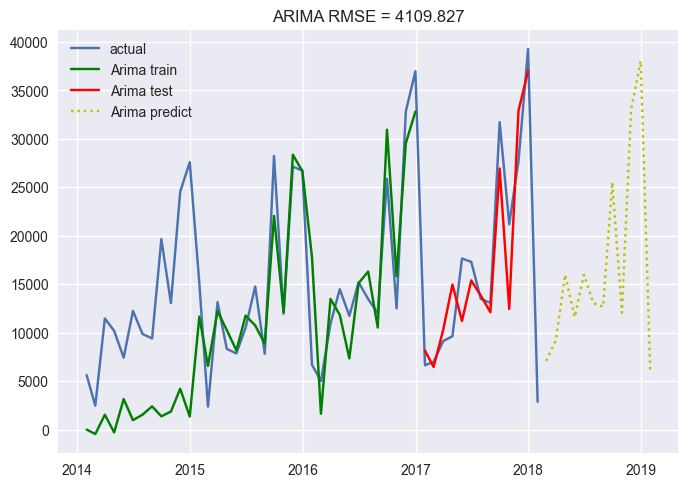

In [89]:
plt.plot(data, label='actual')
plt.plot(best_model.fittedvalues, label = 'Arima train', color='g')
plt.plot(best_model.forecast(12), label = 'Arima test', color='r')
plt.plot(best_model.predict(start='2018-02-28', end='2019-01-31'), label = 'Arima predict', color='y', linestyle=':')

plt.title(f'ARIMA RMSE = {round(best_rmse, 3)}')
plt.legend();

7. Примени регрессионные модели (случайный лес или градиентный бустинг) для прогнозирования целевой величины (применяйте [`TimeSeriesCrossValidation`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html)). 

In [90]:
ml_data = pd.DataFrame(data)

lags = 12

for i in range(1, lags+1):
    ml_data[f'lags_{i}'] = data.shift(i)
    
ml_data = ml_data[12:]

In [91]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [92]:
X, y = ml_data.loc[:, ml_data.columns != 'Sales'], ml_data['Sales']

X_train, X_valid, y_train, y_valid = X[X.index.year < 2017], X[X.index.year >= 2017], y[y.index.year < 2017], y[y.index.year >= 2017]

In [93]:
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

mean_squared_error(y_valid, rf.predict(X_valid), squared=False)

4607.679004065985

8. Построй графики: 
   1. Временной ряд
   2. Прогноз, который построила модель. 

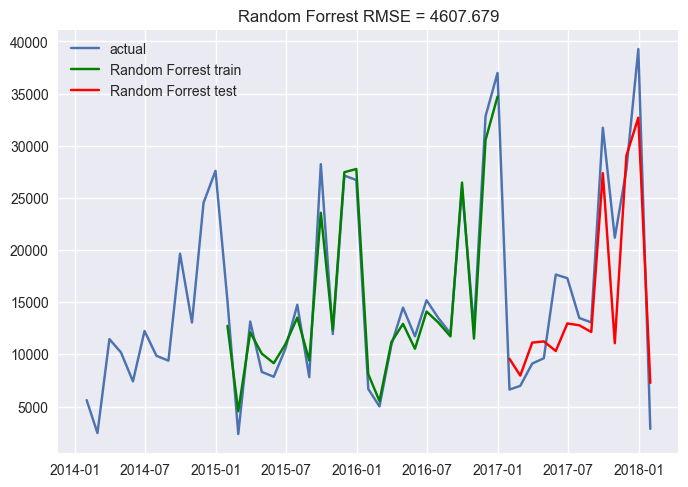

In [94]:
plt.plot(data, label='actual')
plt.plot(data_train.index[lags:], rf.predict(X_train), label = 'Random Forrest train', color='g')
plt.plot(data_test.index, rf.predict(X_valid), label = 'Random Forrest test', color='r')

plt.legend()
plt.title(f'Random Forrest RMSE = {round(mean_squared_error(y_valid, rf.predict(X_valid), squared=False), 3)}');

8. Реши задачу регрессии с применением одной из библиотек: 
- [fbprophet](https://facebook.github.io/prophet/docs/quick_start.html) 
- [tsfresh](https://tsfresh.readthedocs.io/en/latest/text/quick_start.html)
- [autots](https://winedarksea.github.io/AutoTS/build/html/source/tutorial.html)
- [Darts](https://unit8co.github.io/darts/README.html)
- [Kats](https://github.com/facebookresearch/Kats)
- [sktime](https://sktime.org/)

In [95]:
from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import impute
from sklearn.model_selection import train_test_split

In [96]:
data_train = data_train.to_frame(name='Sales')
data_test = data_test.to_frame(name='Sales')

data_train['date'] = data_train.index
data_test['date'] = data_test.index


# # Создание признаков с помощью tsfresh
train_features = extract_features(data_train, column_id='Sales', column_sort='date', column_value='Sales')
test_features = extract_features(data_test, column_id='Sales', column_sort='date', column_value='Sales')

# # Заполнение пропущенных значений
impute(train_features)
impute(test_features)

# Разделение на целевую переменную и признаки
X_train = train_features.copy()
X_valid = test_features.copy()

y_train = train_features.index
y_valid = test_features.index

Feature Extraction: 100%|███████████████████████| 13/13 [00:01<00:00, 10.25it/s]


<img src="https://icons.iconarchive.com/icons/icons8/windows-8/256/Programming-Github-icon.png" width=32 /> Сохрани файл для __github__. 


In [98]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

RandomForestRegressor()

In [99]:
X_train['pred'] = rf.predict(X_train)
X_valid['pred'] = rf.predict(X_valid)


train_res = data_train.join(X_train, on='Sales')[['Sales', 'pred']]
valid_res = data_test.join(X_valid, on='Sales')[['Sales', 'pred']]

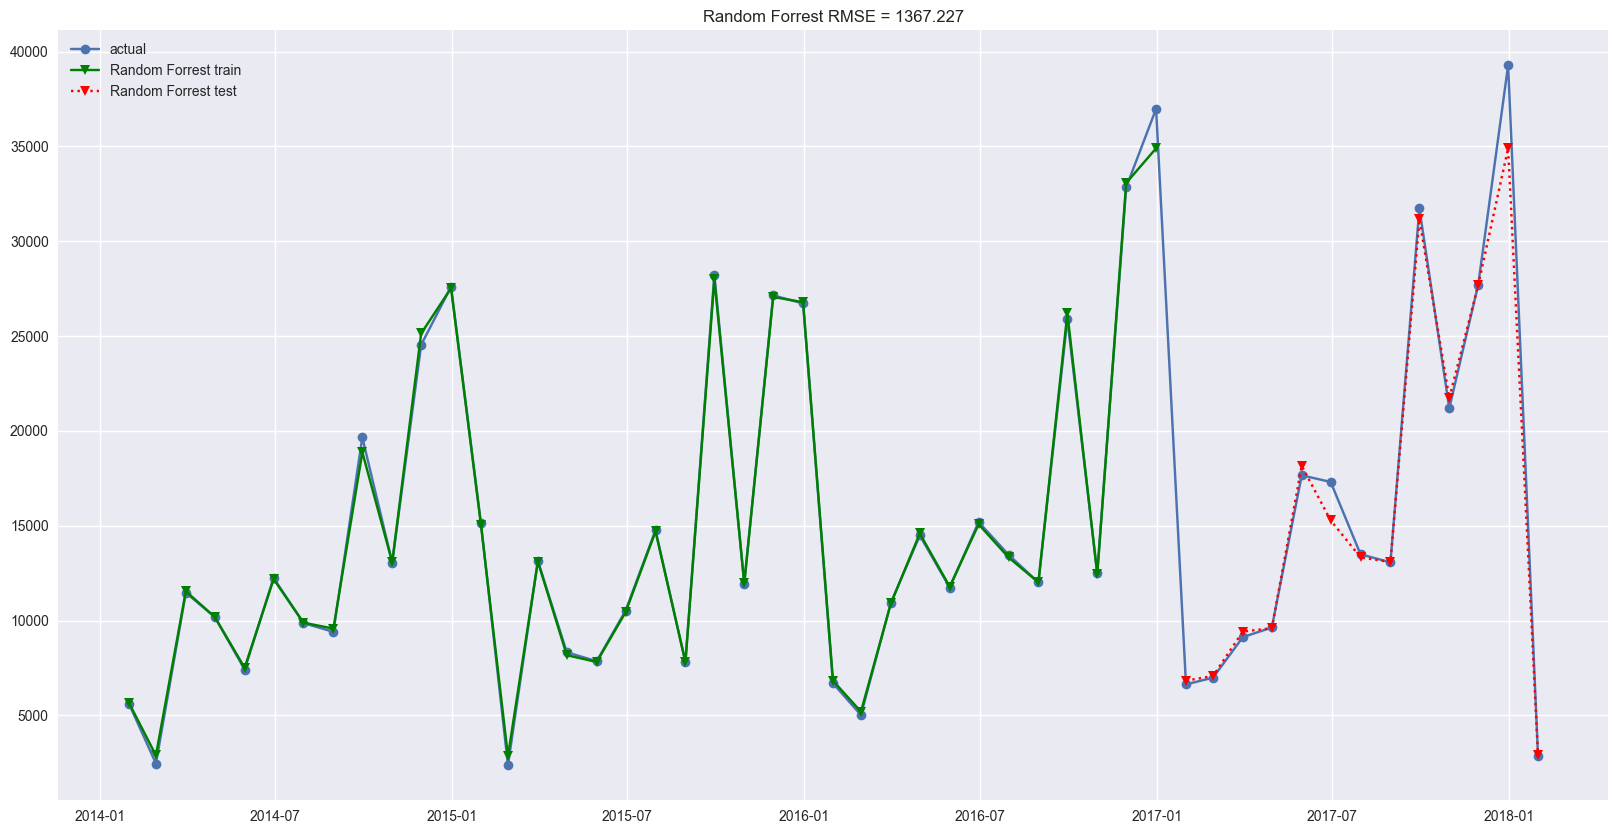

In [100]:
plt.figure(figsize=(20, 10))

plt.plot(data, label='actual', marker='o')
plt.plot(train_res.index, train_res['pred'], label = 'Random Forrest train', color='g', marker='v')
plt.plot(valid_res.index, valid_res['pred'], label = 'Random Forrest test', color='r', marker='v', linestyle=':')

plt.legend()

rmse = round(mean_squared_error(valid_res['Sales'], valid_res['pred'], squared=False), 3)
plt.title(f'Random Forrest RMSE = {rmse}');

In [107]:
feature_importances = pd.Series(dict(zip(train_features.columns, rf.feature_importances_))).sort_values(ascending=False)

Text(0.5, 1.0, 'feature importances')

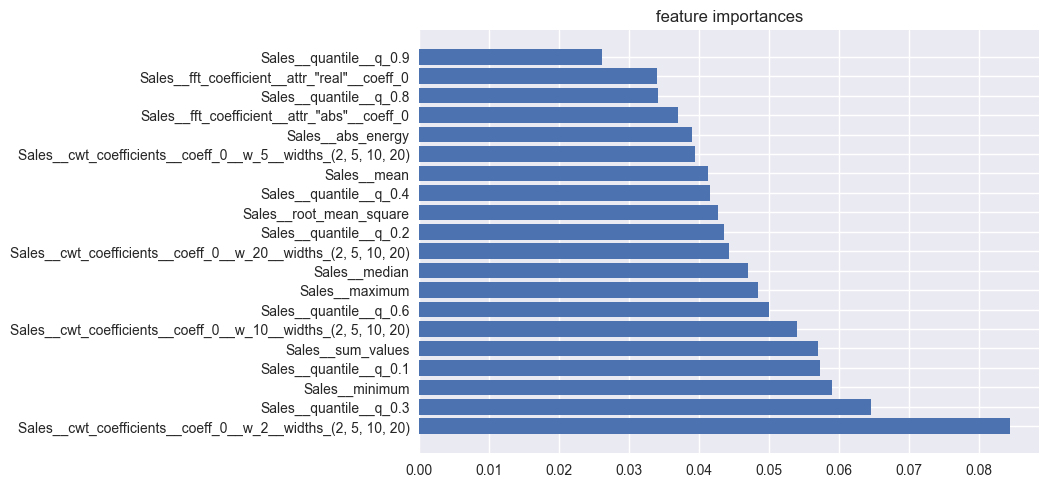

In [108]:
plt.barh(feature_importances.index[:20], feature_importances.values[:20])    
plt.title('feature importances')